In [1]:
def data_clean(df, target=None):
    import pandas as pd
    import numpy as np

    df = df.copy()

    for col in df.columns:

        missing_ratio = df[col].isna().mean()
        unique_ratio = df[col].nunique(dropna=True) / len(df)

       
        if missing_ratio > 0.6 or unique_ratio > 0.85:
            df.drop(columns=[col], inplace=True)
            continue

        
        if df[col].dtype == object:

            if missing_ratio > 0.05:
                df[col] = df[col].fillna("unknown")
            else:
                if not df[col].mode().empty:
                    df[col] = df[col].fillna(df[col].mode()[0])

        
        elif np.issubdtype(df[col].dtype, np.number):

            if missing_ratio <= 0.4:
                df[col] = df[col].fillna(df[col].median())
            else:
                df.drop(columns=[col], inplace=True)

        
        elif pd.api.types.is_datetime64_any_dtype(df[col]):

            if missing_ratio <= 0.5:
                df[col] = df[col].fillna(method="ffill")
            else:
                df.drop(columns=[col], inplace=True)

    return df


In [2]:
def Dashboard(df, target):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import math

    data_clean(df)

    
    categorical_cols = [col for col in df.columns if df[col].dtype == object]

    numeric_cols = [
        col for col in df.columns
        if np.issubdtype(df[col].dtype, np.number) and col != target
    ]

    date_cols = [
        col for col in df.columns
        if pd.api.types.is_datetime64_any_dtype(df[col])
    ]

    
    all_cols = categorical_cols + numeric_cols + date_cols
    n = len(all_cols)
    rows = math.ceil(n / 3)

    
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
    axes = axes.flatten()

   
    for ax, col in zip(axes, all_cols):
        unique_count = df[col].nunique(dropna=True)

        
        if col in categorical_cols:
            data = df.groupby(col)[target].mean()

            if unique_count <= 3:
                ax.pie(data, labels=data.index, autopct='%1.1f%%')
                ax.set_title(col)

            elif 4 <= unique_count <= 7:
                data.plot(kind='bar', ax=ax)
                ax.set_title(f'{target} vs {col}')
                ax.set_ylabel(target)

            else:
                data.sort_values(ascending=False).head(10).plot(kind='bar', ax=ax)
                ax.set_title(f'{target} vs {col} (Top 10)')
                ax.set_ylabel(target)

        
        elif col in date_cols:
            year_data = df[col].dt.year
            df.groupby(year_data)[target].mean().plot(kind='bar', ax=ax)
            ax.set_title(f'{target} by Year')
            ax.set_xlabel('Year')
            ax.set_ylabel(target)

        
        else:
            if unique_count <= 7:
                df.groupby(col)[target].mean().plot(kind='bar', ax=ax)
                ax.set_title(f'{target} vs {col}')
                ax.set_ylabel(target)
            else:
                ax.hist(df[col].dropna(), bins=20)
                ax.set_title(col)
                ax.set_xlabel(col)

    
    for i in range(len(all_cols), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()


In [3]:
import pandas as pd


In [4]:
df=pd.read_csv('/Users/prernasharma/Downloads/SampleSuperstore.csv')

In [5]:
df.head(1)

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.96,2,0.0,41.9136


In [6]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

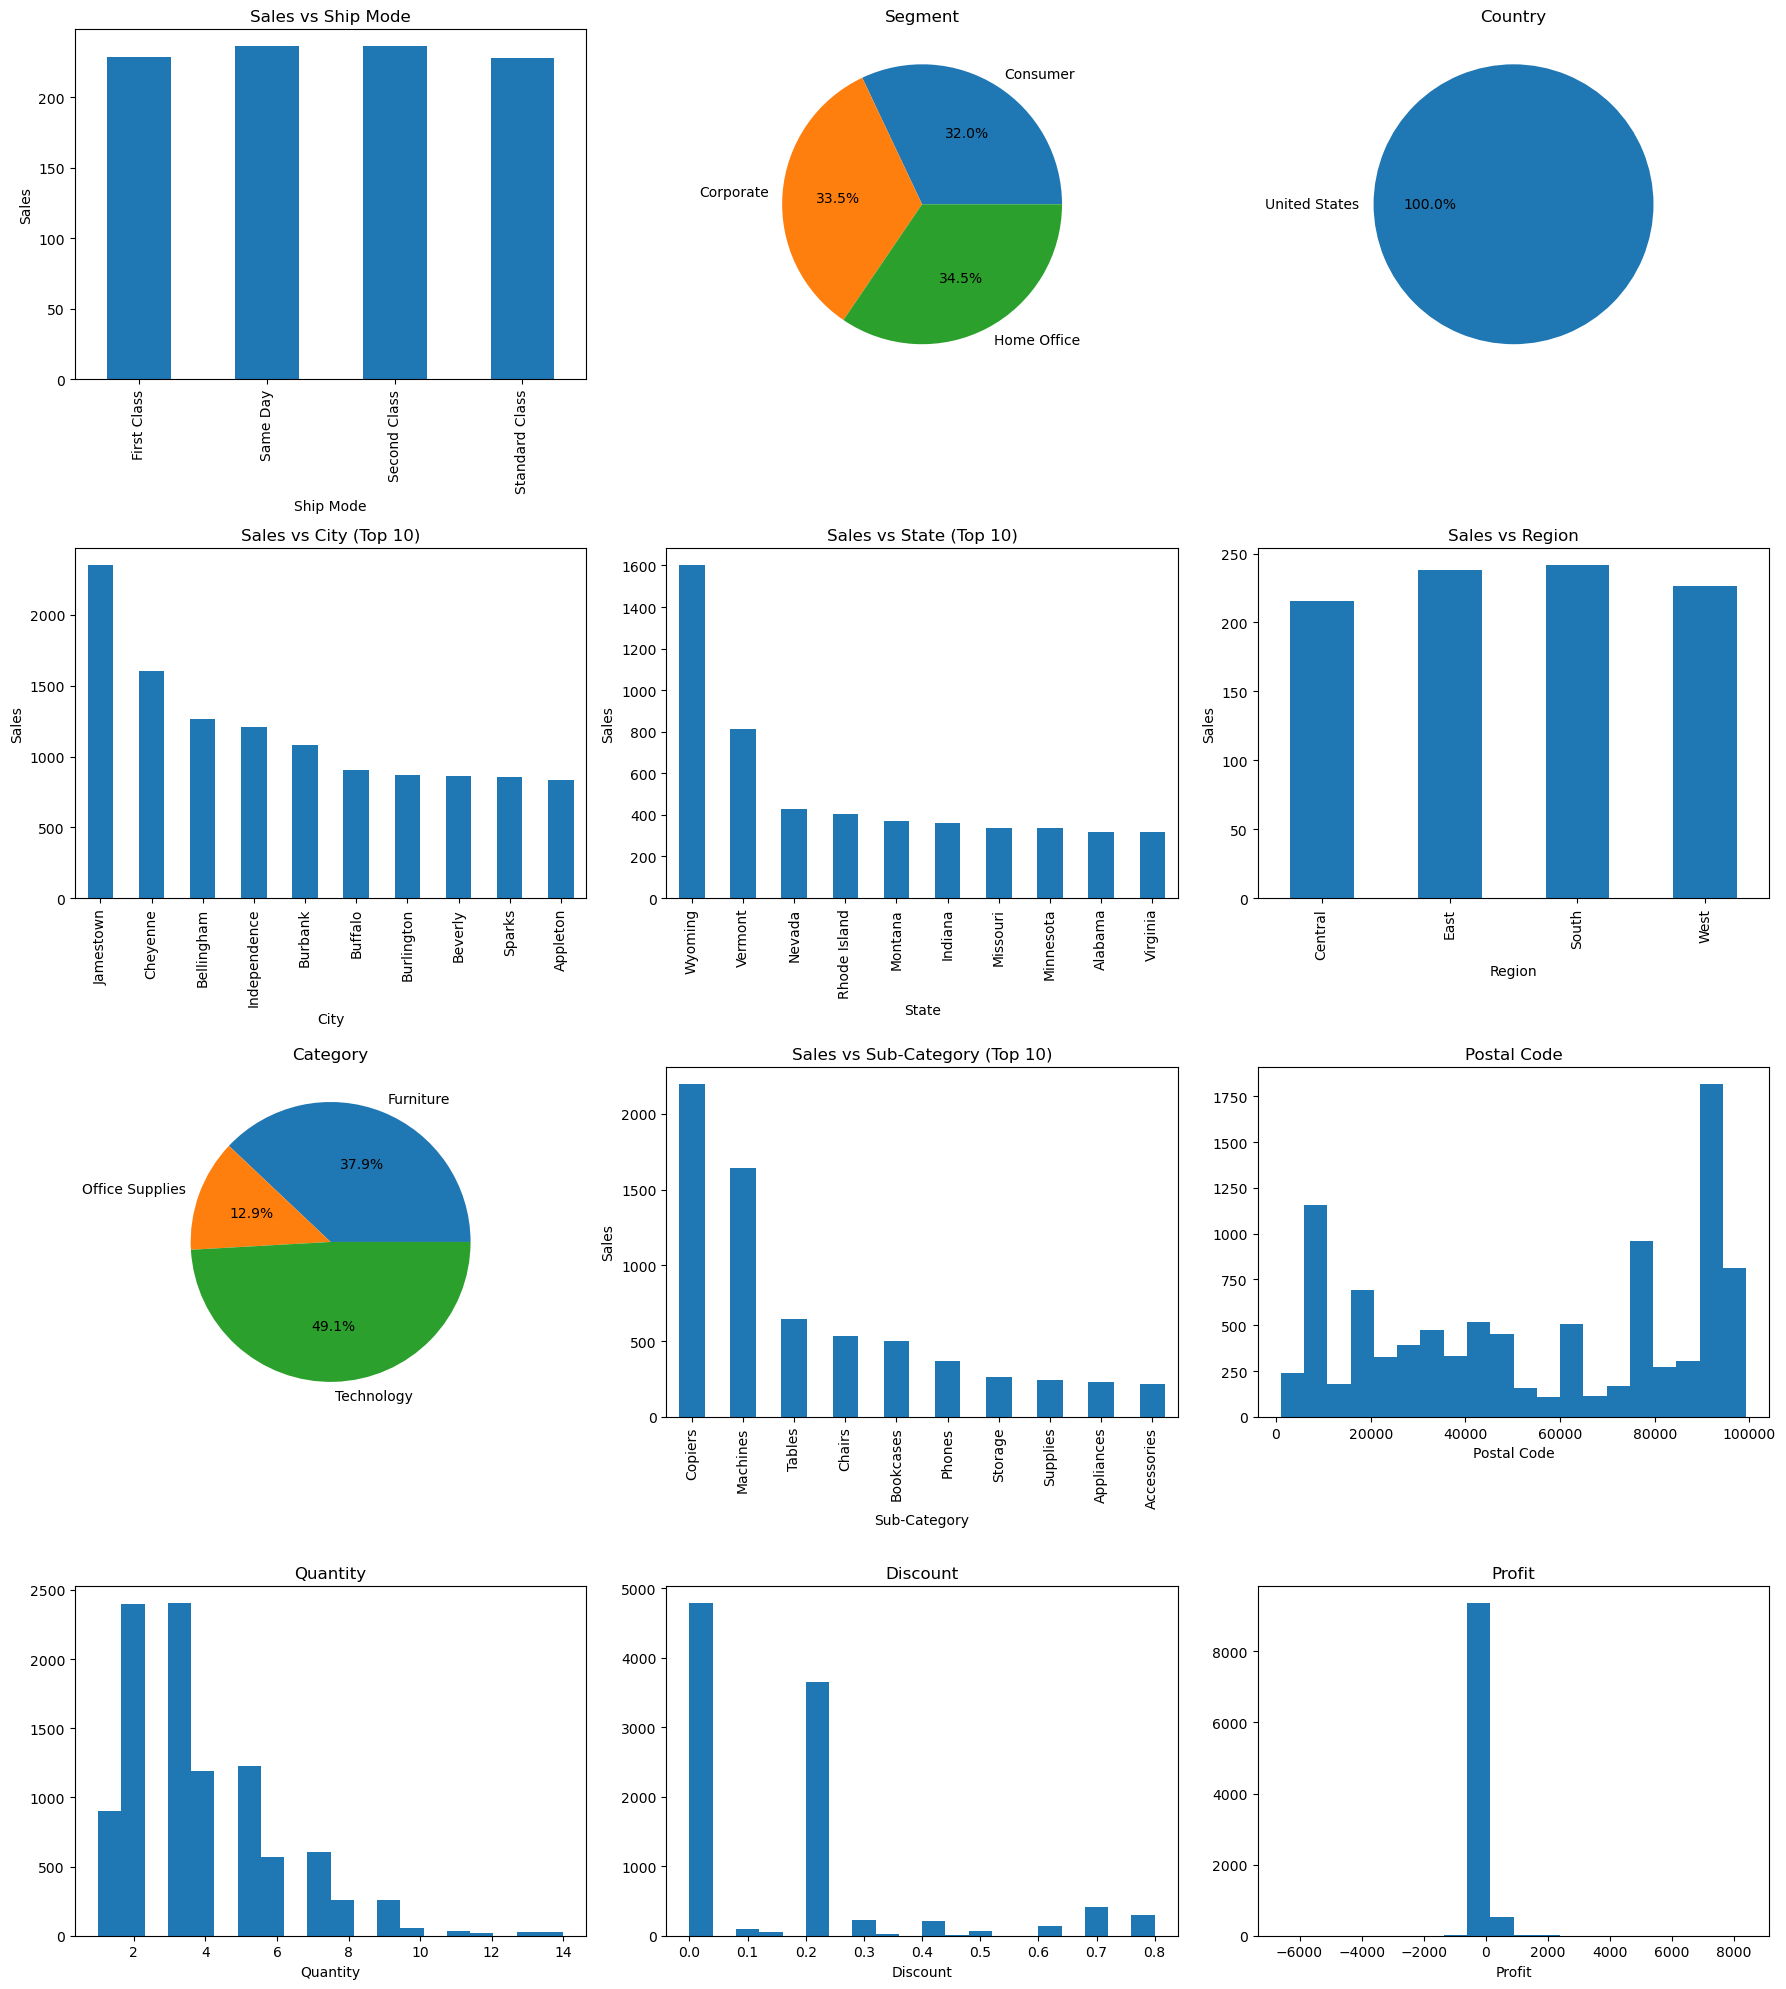

In [7]:
Dashboard(df,"Sales")